# Homework №3


## Effective Flow Matching Training (10 pt)


In this homework, you are asked to:

1) Implement a pixel-space flow matching model ([JiT](https://arxiv.org/abs/2511.13720)) **(6 pt)**

2) Adapt it to the latent diffusion model (i.e., run it in VAE space) **(1 pt)**

3) Implement [REPA](https://openreview.net/forum?id=DJSZGGZYVi) to enforce diffusion to learn internal features faster **(3 pt)**



### Install if required

In [1]:
! wget https://storage.yandexcloud.net/yandex-research/visual-genai/stanford_cars.tar
! wget https://storage.yandexcloud.net/yandex-research/visual-genai/stanford_cars_flat.tar
! wget https://storage.yandexcloud.net/yandex-research/visual-genai/latents_stanford_cars.pt
! tar -xf stanford_cars.tar
! tar -xf stanford_cars_flat.tar

--2026-03-17 14:33:08--  https://storage.yandexcloud.net/yandex-research/visual-genai/stanford_cars.tar
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|2a02:6b8::1d9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 407055998 (388M) [application/x-tar]
Saving to: ‘stanford_cars.tar.1’

stanford_cars.tar.1 100%[===================>] 388.20M   160MB/s    in 2.4s    

2026-03-17 14:33:11 (160 MB/s) - ‘stanford_cars.tar.1’ saved [407055998/407055998]

--2026-03-17 14:33:11--  https://storage.yandexcloud.net/yandex-research/visual-genai/stanford_cars_flat.tar
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|2a02:6b8::1d9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 407070624 (388M) [application/x-tar]
Saving to: ‘stanford_cars_flat.tar.1’

stanford_cars_fla

In [2]:
! pip install torch_fidelity

### Import libraries

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torchvision
import math
import sys
import torch_fidelity
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from transformers import AutoModel

/home/iasudakov/miniconda3/envs/jit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Flow matching implementation (6 pt)

Implement flow matching training and sampling for the pixel-space diffusion transformer, [JiT](https://arxiv.org/abs/2511.13720). 

**Forward process:** $(1-t) x + t \epsilon$

**v-loss:** $\lVert v_\theta - v \rVert^2_2$  

In [32]:
from model_jit import JiT_models


class Denoiser(nn.Module):
    def __init__(self, model='JiT-S/16', img_size=256, in_channels=3, class_num=196, label_drop_prob=0.1, P_mean=0.8, P_std=0.8, t_eps=5e-2):
        super().__init__()
        self.net = JiT_models[model](
            input_size=img_size,
            in_channels=in_channels,
            num_classes=class_num,
        )
        self.in_channels = in_channels
        self.img_size = img_size
        self.num_classes = class_num

        self.label_drop_prob = label_drop_prob
        self.P_mean = P_mean
        self.P_std = P_std
        self.t_eps = t_eps

    def drop_labels(self, labels):
        """
        Implement label dropping during training for CFG (use self.label_drop_prob)
        """
        # <YOUR CODE>
        drop = torch.rand(labels.shape[0], device=labels.device) < self.label_drop_prob
        out = torch.where(drop, torch.full_like(labels, self.num_classes), labels)
        return out
        # <YOUR CODE>

    def sample_t(self, n: int, device=None):
        """ 
        Implement timestep sampling distribution. 
        
        Use shifted logit normal with parameters self.P_std + self.P_mean
        """
        # <YOUR CODE>
        z = torch.randn(n, device=device) * self.P_std + self.P_mean
        return torch.sigmoid(z)
        # <YOUR CODE>

    def forward(self, x, labels, pixel_image=None, dino_encoder=None, repa=None, extractor=None):
        """
        Implement flow matching loss calculation.
        1) Drop labels for CFG
        2) Apply forward process to x
        3) Select the proper prediction type for the model
        4) Compute v-loss
        5) Add the REPA loss (Advice: implement it when you approach the corresponding cell)
        
        Args:
            x: clean images (or latents)
            labels: class labels
            ----------
            REPA args
            ----------
            pixel_image: use it as a DINO input for REPA. Do not forget preprocess is using dino_preprocess_raw_image()
            dino_encoder: DINO encoder for REPA
            repa: REPA class object that implements the feature projector and REPA loss 
            extractor: Extracts intermediate diffusion activations. You can implement this another way - up to you.
        """
        # <YOUR CODE>
        labels_dropped = self.drop_labels(labels) if self.training else labels
        t = self.sample_t(x.shape[0], device=x.device)[:, None, None, None] # <YOUR CODE>
        noise = torch.randn_like(x)

        z = (1 - t) * x + t * noise
        v = (x - z) / (t).clamp_min(self.t_eps)

        x_pred = self.net(z, t.flatten(), labels_dropped)
        v_pred = (x_pred - z) / (t).clamp_min(self.t_eps)

        # FM loss
        loss = ((v - v_pred)**2).mean()

        # REPA loss
        if dino_encoder is not None:
            with torch.no_grad():
                with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                    raw_image_ = dino_preprocess_raw_image(pixel_image).to(dtype=torch.float16)
                    z = dino_encoder(pixel_values=raw_image_)['last_hidden_state'][:, 5:]

                    mean = z.mean(dim=1, keepdim=True)
                    std = z.std(dim=1, keepdim=True)
                    z = (z - mean) / (std + 1e-6)

            activation = extractor.activation[:, self.net.in_context_len:]
            proj_loss = repa(activation, z)
            return loss + proj_loss * 0.5

        return loss

    
    
@torch.no_grad()
def generate(model, labels, steps=25, cfg_scale=4.0, vae=None):
    """
    Implement a flow matching generation process. You are free to use any solver. Euler is okay.
    You can also use any timestep scheduler from the previous HW.
    
    Hints:
        1) Do not forget about CFG. We already set the okay default cfg_scale but you free to play with it
        2) Consider torch.autocast to float16 for faster sampling
        3) (For the latent model) Do not forget to denormalize latents before decoding
    """
    # <YOUR CODE>
    device = labels.device
    bsz = labels.shape[0]
    z = torch.randn(bsz, model.in_channels, model.img_size, model.img_size, device=device)

    timesteps = torch.linspace(1.0, 0.0, steps+1, device=device).unsqueeze(1).expand(-1, bsz)

    # ode
    for i in range(steps - 1):
        t = timesteps[i]
        t_next = timesteps[i + 1]
        v_pred = _forward_sample(model, z, t, labels, cfg_scale)
        z = z + (t - t_next)[0] * v_pred

    # last step euler
    v_pred = _forward_sample(model, z, timesteps[-2], labels, cfg_scale)
    z = z + (timesteps[-2] - timesteps[-1])[0] * v_pred

    if vae is not None:
        z = vae.decode(z / 0.18215).sample
    return z


@torch.no_grad()
def _forward_sample(model, z, t, labels, cfg_scale):
    # conditional
    x_cond = model.net(z, t.flatten(), labels)
    v_cond = (x_cond - z) / (t[0]).clamp_min(model.t_eps)

    # unconditional
    x_uncond = model.net(z, t.flatten(), torch.full_like(labels, model.num_classes))
    v_uncond = (x_uncond - z) / (t[0]).clamp_min(model.t_eps)

    return v_uncond + cfg_scale * (v_cond - v_uncond)

In [3]:
# Recommended hyperparameters

device = torch.device('cuda')
lr = 5e-4
batch_size = 32

### Create dataset and dataloader

We train our model on the [Stanford Cars](https://huggingface.co/datasets/tanganke/stanford_cars) dataset. It contains 16183 images of 196 classes.


**Dataset class returns a clean image, precomputed VAE latent and label.**

Note that you do not need to encode images during latent diffusion training with the VAE encoder.

![dataset](https://storage.yandexcloud.net/yandex-research/visual-genai/stanford_cars_demo.png)

In [4]:
class ImageWithLatentDataset(Dataset):
    def __init__(self, image_folder, latents_file, transform=None):
        self.image_dataset = datasets.ImageFolder(image_folder, transform=transform)
        data = torch.load(latents_file)
        self.latents = data['latents']
        self.labels = data['labels']

    def __len__(self):
        return len(self.image_dataset)

    def __getitem__(self, idx):
        image, label = self.image_dataset[idx]
        latent = self.latents[idx]
        return image, latent, label

    
transform=transforms.Compose([
    transforms.PILToTensor(),
    transforms.Lambda(lambda x: x.float().div(127.5).sub(1.0))
])

dataset_train = ImageWithLatentDataset(
    image_folder='stanford_cars',
    latents_file='latents_stanford_cars.pt',
    transform=transform
)

print(f"Dataset size : {len(dataset_train)}")

data_loader_train = DataLoader(
    dataset_train,
    batch_size=batch_size,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
    shuffle=True,
)

Dataset size : 16183


### Evaluation function

You can use it as is. No coding here

In [5]:
@torch.no_grad()
def evaluate(model, cfg_scale=3.0, batch_size=49, num_images=196, save_folder='samples', vae=None):
    assert num_images % batch_size == 0
    num_steps = num_images // batch_size

    print("Saving to:", save_folder)
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)

    class_num = model.num_classes
    assert num_images % class_num == 0, "Number of images per class must be the same"
    class_label = np.arange(0, class_num).repeat(num_images // class_num)

    for i in range(num_steps):
        start_idx = batch_size * i
        end_idx = start_idx + batch_size
        labels_gen = class_label[start_idx:end_idx]
        labels_gen = torch.Tensor(labels_gen).long().cuda()

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            sampled_images = generate(model, labels_gen, vae=vae, cfg_scale=cfg_scale)

        # denormalize images
        sampled_images = (sampled_images + 1) / 2
        sampled_images = sampled_images.clamp(0, 1)
        sampled_images = sampled_images.detach().cpu()

        # distributed save images
        for b_id in range(sampled_images.size(0)):
            img_id = i * sampled_images.size(0) + b_id

            arr = (sampled_images[b_id].permute(1, 2, 0).float().numpy() * 255).astype(np.uint8)
            Image.fromarray(arr).save(os.path.join(save_folder, f'{img_id:06d}.jpg'), optimize=False, compress_level=1)

    print('saved')

    # # compute FID and IS
    metrics_dict = torch_fidelity.calculate_metrics(
        input1=save_folder,
        input2='stanford_cars_flat',
        kid=True,
        verbose=False,
        kid_subset_size=196,
        kid_subsets=100,
        num_workers=2
    )

    kid_mean = metrics_dict['kernel_inception_distance_mean']
    return kid_mean

### Training function

It is already implemented **BUT**


It is **hightly recommened** (especially for colab/kaggle) to add **mixed-precision** for faster training. 

See the doc: https://docs.pytorch.org/tutorials/recipes/recipes/amp_recipe.html

Note that T4 does not support torch.bfloat16, use torch.float16

In [17]:
def train_model(model, optimizer, max_iters, vae=None, dino_encoder=None, repa=None, extractor=None):
    """
    Trains your flow matching model. 
    
    Consider adding mixed-precision. It will save your time. No other changes are needed.
    """
    
    model.train()
    scaler = torch.amp.GradScaler()

    losses = []
    KIDs = []

    loss_sum = 0
    loss_cnt = 0
    iteration = 0

    while True:
        for (x, latents, labels) in data_loader_train:
            iteration += 1
            latents = latents.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            x = x.to(device, non_blocking=True)

            # <YOUR CODE> Add mixed-precision training
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                if dino_encoder is not None:
                    loss = model(latents, labels, x, dino_encoder, repa, extractor)
                elif vae is not None:
                    loss = model(latents, labels)
                else:
                    loss = model(x, labels)

            loss_sum += loss.item()
            loss_cnt += 1

            # <YOUR CODE> Add mixed-precision
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            
            if iteration % 1000 == 0:
                torch.cuda.empty_cache()
                with torch.no_grad():
                    model.eval()
                    KID = evaluate(model, vae=vae)
                    KIDs.append(KID)
                    model.train()
                torch.cuda.empty_cache()

            if iteration % 100 == 0:
                model.eval()
                with torch.no_grad():
                    with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                        labels_gen = torch.Tensor([0,1,2,3,4,5,6,7]).long().cuda()

                        sampled_images = generate(model, labels_gen, vae=vae)

                        sampled_images = (sampled_images + 1) / 2
                        sampled_images = sampled_images.clamp(0, 1)
                        sampled_images = sampled_images.detach().cpu()

                model.train()

                losses.append(loss_sum/loss_cnt)
                loss_sum = 0
                loss_cnt = 0
                clear_output(wait=True)

                fig = plt.figure(figsize=(14, 6), constrained_layout=True)
                gs = gridspec.GridSpec(2, 8, figure=fig, height_ratios=[2, 1])

                ax1 = fig.add_subplot(gs[0, :4])
                ax1.semilogy(100 * torch.arange(1, len(losses)+1), losses)
                ax1.set_title('Loss')
                ax1.set_xlabel('Iteration')
                ax1.set_ylabel('Loss')
                ax1.grid()

                ax2 = fig.add_subplot(gs[0, 4:])
                ax2.plot(1000 * torch.arange(1, len(KIDs)+1), KIDs)
                ax2.set_title('KID')
                ax2.set_xlabel('Iteration')
                ax2.set_ylabel('KID mean')
                ax2.grid()

                for idx in range(8):
                    ax = fig.add_subplot(gs[1, idx])
                    ax.imshow((sampled_images[idx].permute(1, 2, 0).float().numpy() * 255).astype(np.uint8))
                    ax.axis('off')
                    ax.set_title(f'class {idx}', fontsize=8)

                plt.show()


            if iteration >= max_iters:
                break

        if iteration >= max_iters:
            break

### Using pixel space

In [14]:
model = Denoiser()
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95))

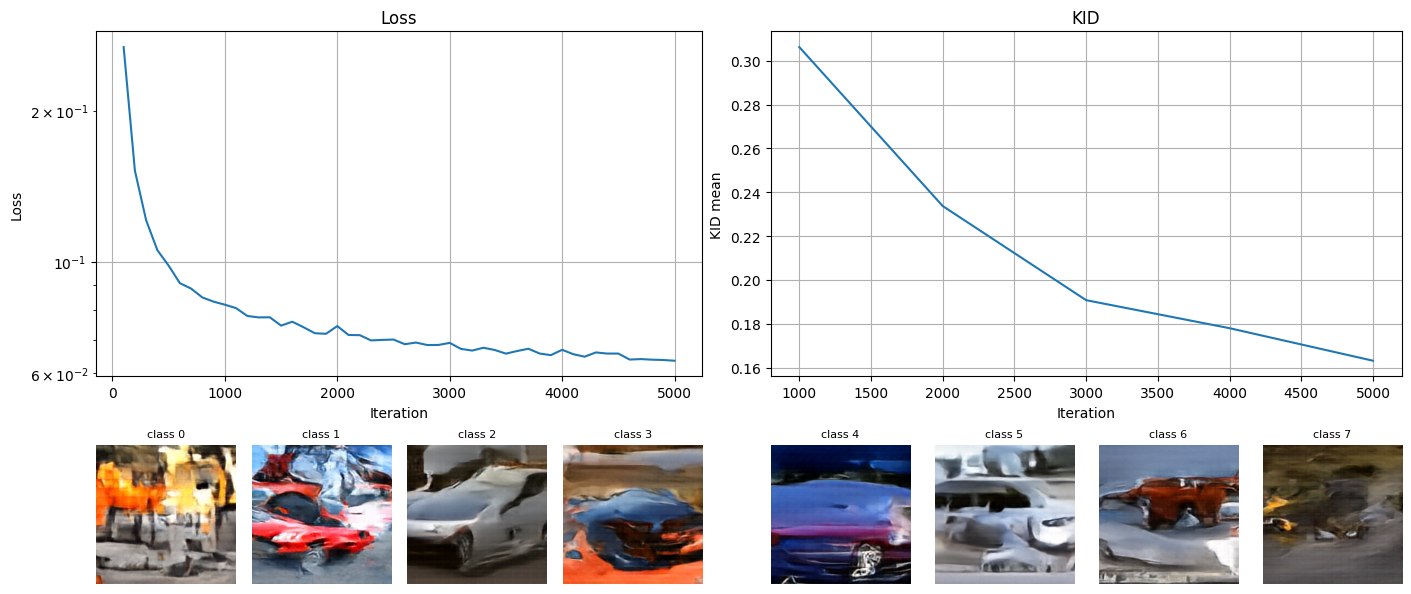

In [15]:
train_model(model, optimizer, 5000) # Consider less iteration for debuggind

## Latent diffusion model (1 pt)

1. Update the generation function to decode latents to images. Remember about denormalization.

2. You need to understand which parameters the Denoiser should take in this case. We want the model to operate on the same number of tokens as in the pixel space (256).

**Hint:** you can define a new patch size via the model name 'JiT-S/X', where X is a new patch size

In [7]:
# Load the VAE model
from diffusers.models import AutoencoderKL
vae = AutoencoderKL.from_pretrained(f"stabilityai/sd-vae-ft-mse").to(device)
vae.eval()
None

/home/iasudakov/miniconda3/envs/jit/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/iasudakov/miniconda3/envs/jit/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [18]:
model = Denoiser(model='JiT-S/2', img_size=32, in_channels=4)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Number of trainable parameters: {:.6f}M".format(n_params / 1e6))
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95))

Number of trainable parameters: 32.624784M


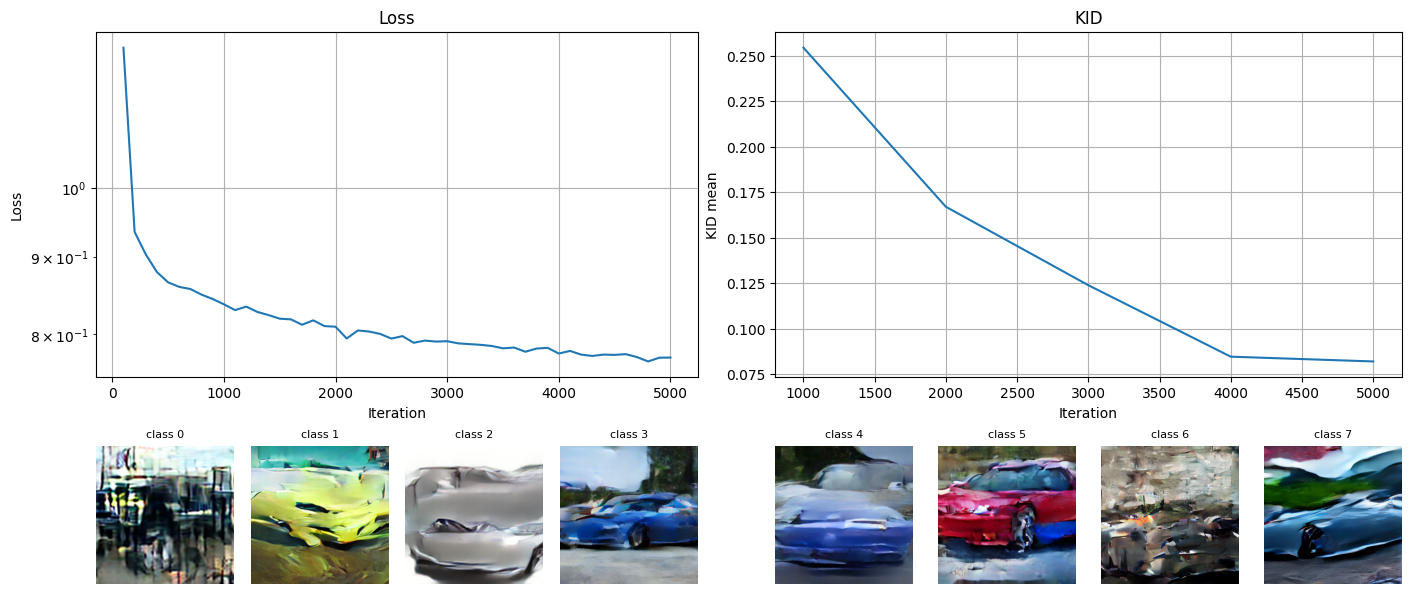

In [19]:
train_model(model, optimizer, 5000, vae=vae)

## REPA loss with [DINOv3](https://arxiv.org/abs/2508.10104) (3 pt)

Implement the **[improved REPA](https://arxiv.org/abs/2512.10794)**. You will need to implement the projection layer and the REPA loss.

In [33]:
##################
# NO CODING CELL #
##################

IMAGENET_DEFAULT_MEAN = (0.485, 0.456, 0.406)
IMAGENET_DEFAULT_STD = (0.229, 0.224, 0.225)

def dino_preprocess_raw_image(x):
    x = (x + 1) / 2
    x = transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD)(x)
    x = torch.nn.functional.interpolate(x, 256, mode='bicubic')
    return x

In [34]:
# ! pip install -U timm

In [35]:
# Load DINOv3: ViT-S/16

encoder = AutoModel.from_pretrained(
    "timm/vit_small_patch16_dinov3.lvd1689m",
    device_map="auto",
).eval()

Loading weights: 100%|██████████| 162/162 [00:00<00:00, 2772.51it/s]


### Extract diffusion features

Implement **ExtractorDiffusionFeatures** that extracts intermediate diffusion features.

Use hooks: https://docs.pytorch.org/docs/stable/generated/torch.Tensor.register_hook.html


**Hints:** 

1) The token sequence contains in_context and spatial tokens. You need only spatial ones
2) We recommend extracting features after the 6th block.

In [37]:
class DiffusionFeatureExtractor:
    # <YOUR CODE>
    def __init__(self, model):
        self.model = model
        self.activation = None
        self.hook = None

    def _make_hook(self, name):
        def hook(module, input, output):
            self.activation = output
        return hook

    def register_hooks(self, block_ind=None):
        self.remove_hooks()
        self.hook = self.model.blocks[block_ind].register_forward_hook(self._make_hook(f"block_{block_ind}"))

    def remove_hooks(self):
        if self.hook is not None:
            self.hook.remove()

    def clear_activations(self):
        self.activation = None

    def __enter__(self):
        return self

    def __exit__(self, *args):
        self.remove_hooks()
    
    

class REPA(nn.Module):
    def __init__(self, **kwargs):
        """ 
        Create the projection layer according to the iREPA. 
        """
        # <YOUR CODE>
        super().__init__()
        self.net_hidden_size = kwargs["net_hidden_size"]
        in_ch = kwargs["hidden_size"]
        out_ch = kwargs["z_dim"]
        kernel_size = kwargs["kernel_size"]
        padding = kwargs["kernel_size"] // 2
        self.projection_layer = nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, stride=1, padding=padding)
        
    def forward(self, dm_features, dino_features):
        """
        Implement the REPA loss using the projection model
        
        Args:
            dm_features [B, 256, D]: Extracted diffusion features
            dino_features [B, 256, D]: DINO features    
        """
        
        B = dm_features.shape[0]
        T = 256
        D = self.net_hidden_size

        H = W = int(math.isqrt(T))
        assert H * W == T, f"conv projector needs square grid or pass hw; got T={T}"
        # [B, T, D] -> [B, D, H, W]
        x_ = dm_features.reshape(B, H, W, D).permute(0, 3, 1, 2).contiguous()
        y  = self.projection_layer(x_)                  # [B, z_dim, H, W]
        y  = y.permute(0, 2, 3, 1).contiguous()         # [B, H, W, z_dim]
        z_tilde = y.reshape(B, T, -1)

        repa_loss = 0.
        bsz = dino_features.shape[0]
        for j, (z_j, z_tilde_j) in enumerate(zip(dino_features, z_tilde)):
            z_tilde_j = torch.nn.functional.normalize(z_tilde_j, dim=-1)
            z_j = torch.nn.functional.normalize(z_j, dim=-1)
            repa_loss += (-(z_j * z_tilde_j).sum(dim=-1)).mean()

        repa_loss /= bsz

        return repa_loss

In [38]:
# Create the latent denoiser, extractor and repa. 

z_dim = 384
net_hidden_size = 384
projector_dim=2048
kernel_size = 3

model = Denoiser(model='JiT-S/2', img_size=32, in_channels=4)
model.to(device)
extractor =  DiffusionFeatureExtractor(model.net)
extractor.register_hooks(block_ind=6)
repa = REPA(net_hidden_size=net_hidden_size, hidden_size=model.net.hidden_size, z_dim=z_dim, projector_dim=projector_dim, kernel_size=kernel_size).to(device)

optimizer = torch.optim.AdamW(list(model.parameters()) + list(repa.parameters()), lr=lr, betas=(0.9, 0.95))

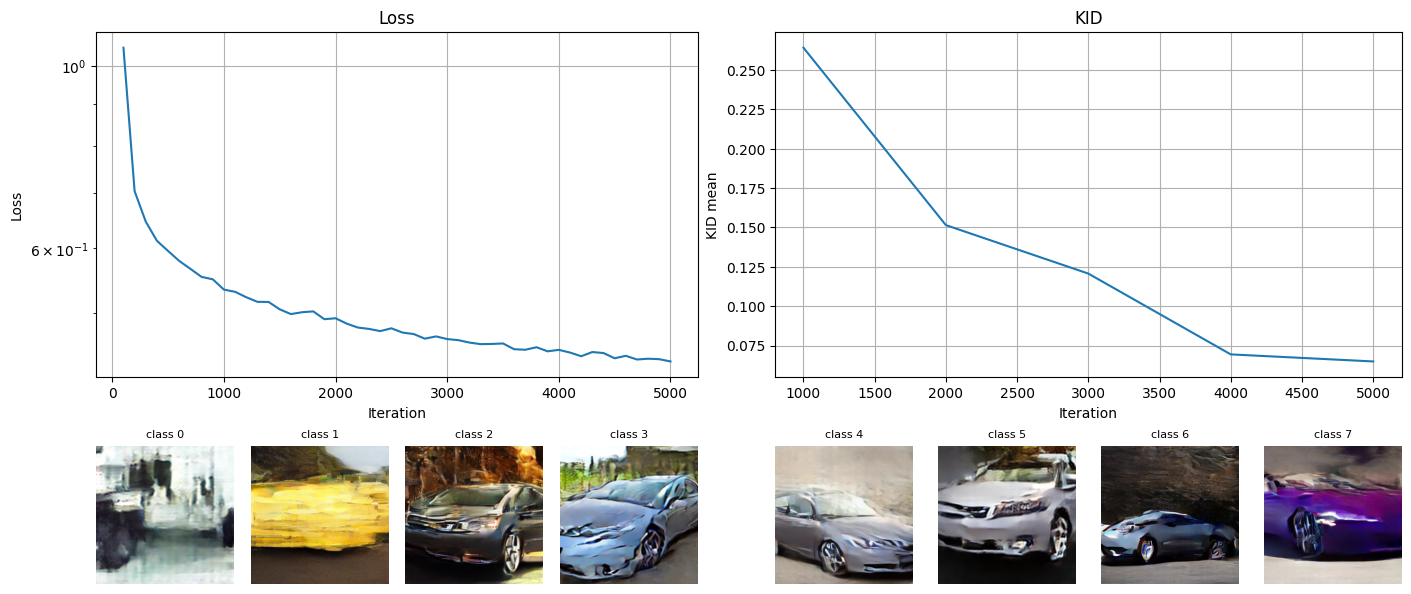

In [39]:
# Consider less iteration for debugging
train_model(model, optimizer, 5000, vae=vae, dino_encoder=encoder, repa=repa, extractor=extractor)

## Conclusions

Please discuss the design choices and techniques that led to noticeable improvements, such as faster convergence or better overall results.

**YOUR CONCLUSIONS**

---
### Example of training in pixel space
![dataset](https://storage.yandexcloud.net/yandex-research/visual-genai/stanford_cars_demo_pixel_space.png)

### Example of training in latent space
![dataset](https://storage.yandexcloud.net/yandex-research/visual-genai/stanford_cars_demo_latent_space.png)

### Example of training in latent space with REPA loss
![dataset](https://storage.yandexcloud.net/yandex-research/visual-genai/stanford_cars_demo_repa.png)